<a href="https://colab.research.google.com/github/turayusa/homework/blob/main/Homework_06_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 06: Decision Trees

#### Due Date: Sunday, October 11th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 603 Syllabus.

### Introduction

In the previous homework, we used logistic regression for **binary classification** and evaluated models using metrics such as accuracy, TPR, FPR, and ROC AUC. In this homework, we turn to a fundamentally different type of model: **decision trees**.

Decision trees can capture nonlinear relationships and interactions between variables, but they also introduce several hyperparameters that control model complexity. We will use the **UCI MAGIC Gamma Telescope** dataset to explore how these choices affect training and cross-validation performance.

In this homework, you will:

- Establish a **Logistic Regression baseline** for comparison.
- Explore the effects of `max_depth`, `min_samples_leaf`, and `min_samples_split` using validation curves.
- Compare **training and cross-validation performance** to identify underfitting and overfitting.
- Explore combinations of hyperparameters to see how their effects can **interact**.
- Investigate **cost-complexity pruning** using `ccp_alpha`.
- Compare the best **pre-pruned** and **cost-complexity-pruned** decision trees.
- Compare candidate models using **cross-validated ROC curves**.
- Select a final model using cross-validation, refit it on the complete development set, and evaluate it once on the untouched test set.

Decision trees are the first models we have studied with several important hyperparameters that can interact with one another. This makes model selection more challenging because we are no longer choosing among values of just one setting.

In this homework, we will begin **exploring this hyperparameter space manually.** You will first vary individual hyperparameters, then investigate combinations of promising values. This will help you see how different settings affect model complexity, underfitting, overfitting, and generalization.

Next week, when we study ensemble methods, we will introduce automated hyperparameter search to explore larger parameter spaces more efficiently. The manual exploration in this homework will provide the intuition needed to understand and use those methods effectively.

As in previous homeworks, the **test set should remain untouched during model development**. Cross-validation on the development set will be used to tune hyperparameters and compare candidate models. The test set will be used only once, after the final model has been selected.

> You are **not expected to write every scikit-learn model or evaluation procedure from scratch**. Reuse and adapt code from the Week 5 and Week 6 Coding Notebooks, and use AI to help you generate or modify code when appropriate. You are responsible for **understanding** the code, running the code, checking that it follows the instructions, and interpreting the results.

### Grading

- All homeworks in DX 603 are worth **80 points**.
- Problems 1–7 contain the coding and model-analysis portions of the homework.
- Problem 8 is a **multiple-choice** problem.
- Problem 9 is a **reflection** problem.
- Problem 5 is worth 8 points and all the other problems are worth 9 points.
- Multi-part problems will have approximately equal points for each subpart.

You may submit a regrade request on Gradescope after your grades are released. The instructor will review the request and make any appropriate adjustment.

In [1]:
# Useful imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone

from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


# --------------------------------------------------
# Globals
# --------------------------------------------------

random_seed = 42

In [2]:

# --------------------------------------------------
# Load the MAGIC Gamma Telescope dataset
# --------------------------------------------------

url = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "magic/magic04.data"
)

column_names = [
    "fLength",
    "fWidth",
    "fSize",
    "fConc",
    "fConc1",
    "fAsym",
    "fM3Long",
    "fM3Trans",
    "fAlpha",
    "fDist",
    "class"
]

df = pd.read_csv(
    url,
    names=column_names
)

# Separate predictors and target
X = df.drop(columns="class")

# gamma = 1, hadron = 0
y = (df["class"] == "g").astype(int)

# --------------------------------------------------
# Development / Test Split
# --------------------------------------------------

random_seed = 42

X_development, X_test, y_development, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    stratify=y,
    random_state=random_seed
)

print("Development set:", X_development.shape)
print("Test set:       ", X_test.shape)

print("\nTarget proportions:")
print(y.value_counts(normalize=True).sort_index())

Development set: (17118, 10)
Test set:        (1902, 10)

Target proportions:
class
0    0.35163
1    0.64837
Name: proportion, dtype: float64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   fLength   19020 non-null  float64
 1   fWidth    19020 non-null  float64
 2   fSize     19020 non-null  float64
 3   fConc     19020 non-null  float64
 4   fConc1    19020 non-null  float64
 5   fAsym     19020 non-null  float64
 6   fM3Long   19020 non-null  float64
 7   fM3Trans  19020 non-null  float64
 8   fAlpha    19020 non-null  float64
 9   fDist     19020 non-null  float64
 10  class     19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB


> **Note:** The only categorical column is `class,` which is the target rather than a predictor. We convert it to a binary target with gamma events coded as 1 and hadron events coded as 0. All predictor variables are numeric, so no categorical feature encoding is needed.

In [4]:
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


Number of predictors: 10

Target counts:
class
g    12332
h     6688
Name: count, dtype: int64

Target proportions:
class
g    0.64837
h    0.35163
Name: proportion, dtype: float64

Missing values by predictor:
No missing values.

Numeric predictor summaries:


,count,mean,std,min,25%,50%,75%,max
fLength,19020.00,53.25,42.36,4.28,24.34,37.15,70.12,334.18
fWidth,19020.00,22.18,18.35,0.00,11.86,17.14,24.74,256.38
fSize,19020.00,2.83,0.47,1.94,2.48,2.74,3.10,5.32
fConc,19020.00,0.38,0.18,0.01,0.24,0.35,0.50,0.89
fConc1,19020.00,0.21,0.11,0.00,0.13,0.20,0.29,0.68
fAsym,19020.00,-4.33,59.21,-457.92,-20.59,4.01,24.06,575.24
fM3Long,19020.00,10.55,51.00,-331.78,-12.84,15.31,35.84,238.32
fM3Trans,19020.00,0.25,20.83,-205.89,-10.85,0.67,10.95,179.85
fAlpha,19020.00,27.65,26.10,0.00,5.55,17.68,45.88,90.00
fDist,19020.00,193.82,74.73,1.28,142.49,191.85,240.56,495.56


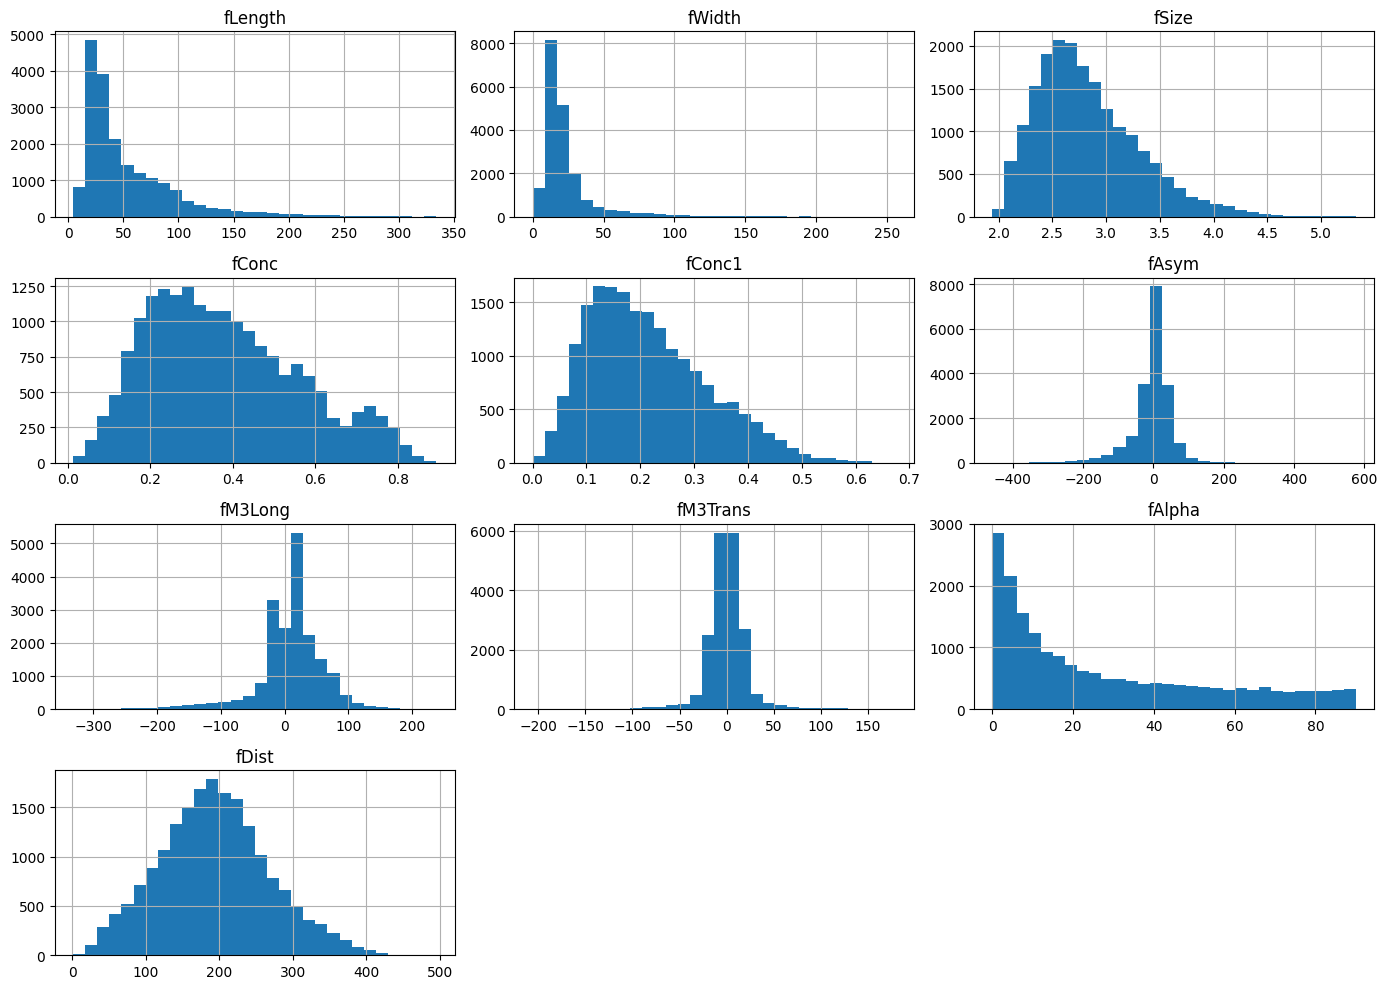

In [5]:
# --------------------------------------------------
# Basic EDA
# --------------------------------------------------

# All predictors are numeric
numeric_cols = df.drop(columns="class").columns

print("Number of predictors:", len(numeric_cols))


# --------------------------------------------------
# Target distribution
# --------------------------------------------------

print("\nTarget counts:")
print(df["class"].value_counts())

print("\nTarget proportions:")
print(df["class"].value_counts(normalize=True))


# --------------------------------------------------
# Missing values
# --------------------------------------------------

print("\nMissing values by predictor:")
missing_counts = df[numeric_cols].isna().sum()

if missing_counts.sum() == 0:
    print("No missing values.")
else:
    print(missing_counts[missing_counts > 0])


# --------------------------------------------------
# Numeric predictor summaries
# --------------------------------------------------

print("\nNumeric predictor summaries:")

display(
    df[numeric_cols]
    .describe()
    .T
    .style.format("{:.2f}")
)


# --------------------------------------------------
# Histograms of numeric predictors
# --------------------------------------------------

df[numeric_cols].hist(
    bins=30,
    figsize=(14, 10)
)

plt.tight_layout()
plt.show()

## Problem 1 — Logistic Regression Baseline

Using the **Week 5 coding notebook** as a guide, build a Logistic Regression baseline for the MAGIC Gamma Telescope dataset.

Using the Week 5 and Week 6 coding notebooks as guides, create:
- a StandardScaler + LogisticRegression pipeline named logistic_model
- a 5-fold, 5-repeat RepeatedStratifiedKFold object named repeated_cv, using random_seed

Using the **development set only**:

- Use repeated cross-validation to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the Logistic Regression model on the complete development set.
- Compute:
  - training ROC AUC
  - training accuracy

Display all four values, rounded to four decimal places.

Do **not** use the test set in this problem.

Store your answer in:

```python
a1 = ...
```

where `a1` is the **mean cross-validation ROC AUC** for the Logistic Regression baseline.


In [6]:
# Your code here, add additional cells as needed
# --------------------------------------------------
# Problem 1: Logistic Regression Baseline
# --------------------------------------------------

# 1A. Create a scaling and logistic regression pipeline
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=2000,
        random_state=random_seed
    ))
])

# 1B. Set up 5-fold cross-validation repeated 5 times
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=random_seed
)

# 1C. Evaluate using DEVELOPMENT data only
logistic_cv_results = cross_validate(
    estimator=logistic_model,
    X=X_development,
    y=y_development,
    cv=repeated_cv,
    scoring={
        "auc": "roc_auc",
        "accuracy": "accuracy"
    },
    n_jobs=-1,
    error_score="raise"
)

logistic_mean_cv_auc = logistic_cv_results["test_auc"].mean()
logistic_mean_cv_accuracy = (
    logistic_cv_results["test_accuracy"].mean()
)

# 1D. Fit the pipeline on the complete development set
logistic_model.fit(X_development, y_development)

# Probabilities for AUC; class labels for accuracy
logistic_train_probabilities = logistic_model.predict_proba(
    X_development
)[:, 1]

logistic_train_predictions = logistic_model.predict(
    X_development
)

logistic_train_auc = roc_auc_score(
    y_development,
    logistic_train_probabilities
)

logistic_train_accuracy = accuracy_score(
    y_development,
    logistic_train_predictions
)

# 1E. Display the four required results
print("Logistic Regression Baseline")
print(f"Mean CV ROC AUC:   {logistic_mean_cv_auc:.4f}")
print(f"Mean CV accuracy:  {logistic_mean_cv_accuracy:.4f}")
print(f"Training ROC AUC:  {logistic_train_auc:.4f}")
print(f"Training accuracy:{logistic_train_accuracy: .4f}")

Logistic Regression Baseline
Mean CV ROC AUC:   0.8395
Mean CV accuracy:  0.7921
Training ROC AUC:  0.8400
Training accuracy: 0.7923


In [7]:
# Your answer here, NOT in the next cell

a1 = float(logistic_mean_cv_auc)      # Replace with the mean cross-validation ROC AUC

In [8]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1 = {a1:,.4f}')

a1 = 0.8395


## Problem 2 — Explore Decision-Tree Hyperparameters

Decision trees provide several hyperparameters for controlling model complexity. In this problem, you will investigate three of them separately before exploring combinations in the next problem.

### Part A — `max_depth`

Using the decision-tree sweep pattern from the Week 6 coding notebook, investigate how `max_depth` affects model performance.

For each value in

```python
depth_values = range(1, 21)
```

do the following:

- Build a `DecisionTreeClassifier` using that value of `max_depth`.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set and compute its training ROC AUC.
- Store the results for all values of `max_depth`.
- Plot **training AUC and mean CV AUC** versus `max_depth`.
- Plot **mean CV accuracy** versus `max_depth`.
- Identify the value of `max_depth` with the highest mean CV AUC.

Store your answer in:

```python
a2a = ...
```

where `a2a` is the selected value of `max_depth`.


Depth  1/20 completed | Training AUC: 0.7241 | CV AUC: 0.7229 | CV accuracy: 0.7318
Depth  2/20 completed | Training AUC: 0.7986 | CV AUC: 0.7967 | CV accuracy: 0.7917
Depth  3/20 completed | Training AUC: 0.8410 | CV AUC: 0.8314 | CV accuracy: 0.7925
Depth  4/20 completed | Training AUC: 0.8618 | CV AUC: 0.8512 | CV accuracy: 0.8163
Depth  5/20 completed | Training AUC: 0.8795 | CV AUC: 0.8666 | CV accuracy: 0.8260
Depth  6/20 completed | Training AUC: 0.8924 | CV AUC: 0.8744 | CV accuracy: 0.8369
Depth  7/20 completed | Training AUC: 0.9022 | CV AUC: 0.8771 | CV accuracy: 0.8411
Depth  8/20 completed | Training AUC: 0.9118 | CV AUC: 0.8730 | CV accuracy: 0.8446
Depth  9/20 completed | Training AUC: 0.9247 | CV AUC: 0.8633 | CV accuracy: 0.8445
Depth 10/20 completed | Training AUC: 0.9381 | CV AUC: 0.8509 | CV accuracy: 0.8447
Depth 11/20 completed | Training AUC: 0.9496 | CV AUC: 0.8355 | CV accuracy: 0.8422
Depth 12/20 completed | Training AUC: 0.9589 | CV AUC: 0.8212 | CV accuracy:

,max_depth,training_auc,mean_cv_auc,mean_cv_accuracy
0,1,0.7241,0.7229,0.7318
1,2,0.7986,0.7967,0.7917
2,3,0.8410,0.8314,0.7925
3,4,0.8618,0.8512,0.8163
4,5,0.8795,0.8666,0.8260
5,6,0.8924,0.8744,0.8369
6,7,0.9022,0.8771,0.8411
7,8,0.9118,0.8730,0.8446
8,9,0.9247,0.8633,0.8445
9,10,0.9381,0.8509,0.8447



Selected max_depth: 7
Best mean CV AUC: 0.8771


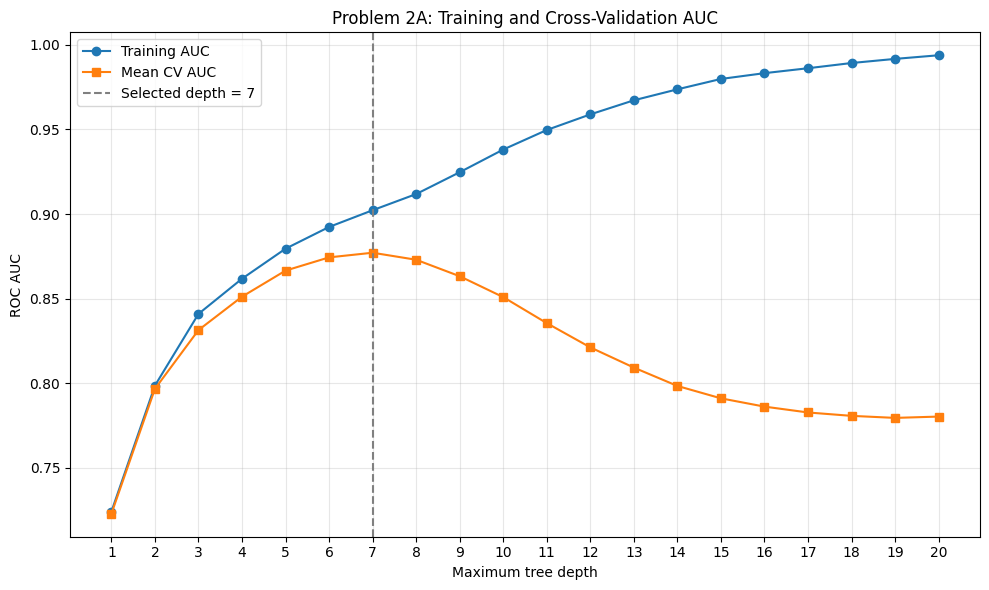

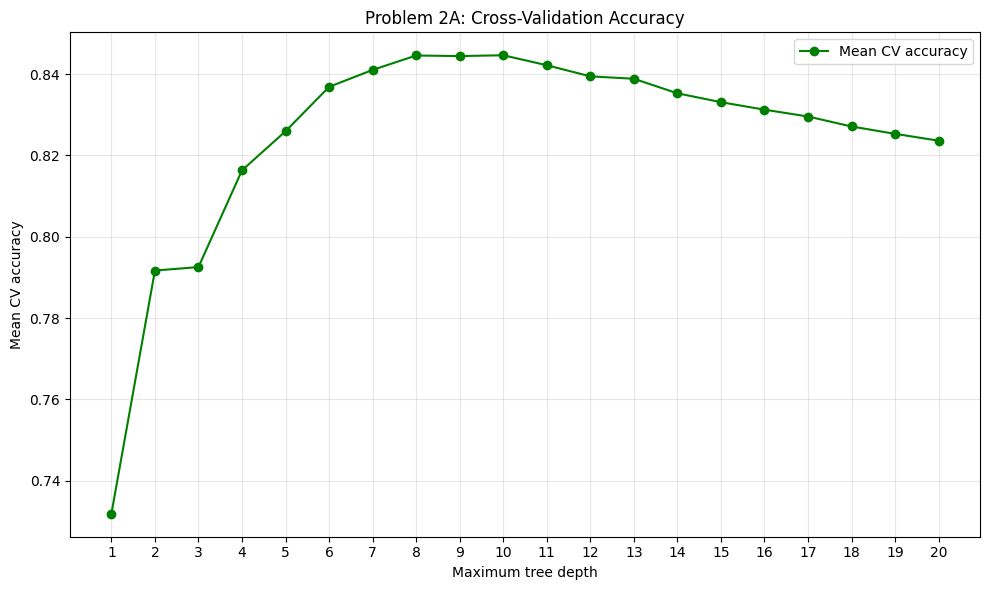

In [9]:
# Your code here, as more cells as needed

# --------------------------------------------------
# Problem 2A: Explore max_depth
# --------------------------------------------------

depth_values = range(1, 21)
depth_results = []

for depth in depth_values:

    # Build a tree with this maximum depth
    tree_model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=random_seed
    )

    # Evaluate using development data only
    cv_results = cross_validate(
        estimator=tree_model,
        X=X_development,
        y=y_development,
        cv=repeated_cv,
        scoring={
            "auc": "roc_auc",
            "accuracy": "accuracy"
        },
        n_jobs=-1,
        error_score="raise"
    )

    mean_cv_auc = cv_results["test_auc"].mean()
    mean_cv_accuracy = cv_results["test_accuracy"].mean()

    # Fit on all development data for training AUC
    tree_model.fit(X_development, y_development)

    training_probabilities = tree_model.predict_proba(
        X_development
    )[:, 1]

    training_auc = roc_auc_score(
        y_development,
        training_probabilities
    )

    # Save results for later comparisons
    depth_results.append({
        "max_depth": depth,
        "training_auc": training_auc,
        "mean_cv_auc": mean_cv_auc,
        "mean_cv_accuracy": mean_cv_accuracy
    })

    print(
        f"Depth {depth:2d}/20 completed | "
        f"Training AUC: {training_auc:.4f} | "
        f"CV AUC: {mean_cv_auc:.4f} | "
        f"CV accuracy: {mean_cv_accuracy:.4f}",
        flush=True
    )

# Convert results into a table
depth_results_df = pd.DataFrame(depth_results)

print("\nResults for all depths:")
display(depth_results_df.round(4))

# Select using full-precision mean CV AUC
# If tied, idxmax selects the first (shallower) depth.
best_depth_index = depth_results_df["mean_cv_auc"].idxmax()
best_depth_row = depth_results_df.loc[best_depth_index]
best_depth = int(best_depth_row["max_depth"])

print(f"\nSelected max_depth: {best_depth}")
print(f"Best mean CV AUC: {best_depth_row['mean_cv_auc']:.4f}")

# --------------------------------------------------
# Plot 1: Training and mean CV AUC
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    depth_results_df["max_depth"],
    depth_results_df["training_auc"],
    marker="o",
    label="Training AUC"
)

plt.plot(
    depth_results_df["max_depth"],
    depth_results_df["mean_cv_auc"],
    marker="s",
    label="Mean CV AUC"
)

plt.axvline(
    best_depth,
    color="gray",
    linestyle="--",
    label=f"Selected depth = {best_depth}"
)

plt.xlabel("Maximum tree depth")
plt.ylabel("ROC AUC")
plt.title("Problem 2A: Training and Cross-Validation AUC")
plt.xticks(list(depth_values))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# --------------------------------------------------
# Plot 2: Mean CV accuracy
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    depth_results_df["max_depth"],
    depth_results_df["mean_cv_accuracy"],
    marker="o",
    color="green",
    label="Mean CV accuracy"
)

plt.xlabel("Maximum tree depth")
plt.ylabel("Mean CV accuracy")
plt.title("Problem 2A: Cross-Validation Accuracy")
plt.xticks(list(depth_values))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [10]:
# Your answer here, NOT in the next cell

a2a = best_depth      # Replace with the selected value of `max_depth`.

In [11]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2a = {a2a}')

a2a = 7


### Part B — `min_samples_leaf`

Using the same general sweep procedure as in Part A, investigate how `min_samples_leaf` affects model performance.

Choose a reasonable range of values for `min_samples_leaf` that includes both small and substantially larger leaf sizes.

For each value:

- Build a `DecisionTreeClassifier` using that value of `min_samples_leaf`.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set and compute its training ROC AUC.
- Store the results.
- Plot **training AUC and mean CV AUC** versus `min_samples_leaf`.
- Plot **mean CV accuracy** versus `min_samples_leaf`.
- Identify the value with the highest mean CV AUC.

Store your answer in:

```python
a2b = ...
```

where `a2b` is the selected value of `min_samples_leaf`.

**Hint:** Since useful values may span a fairly wide range, a roughly multiplicative sequence such as 1, 2, 5, 10, 20, 50, … may be helpful.

Leaf size   1 completed | Training AUC: 1.0000 | CV AUC: 0.7970 | CV accuracy: 0.8141
Leaf size   2 completed | Training AUC: 0.9981 | CV AUC: 0.8192 | CV accuracy: 0.8090
Leaf size   5 completed | Training AUC: 0.9879 | CV AUC: 0.8560 | CV accuracy: 0.8237
Leaf size  10 completed | Training AUC: 0.9731 | CV AUC: 0.8768 | CV accuracy: 0.8317
Leaf size  20 completed | Training AUC: 0.9566 | CV AUC: 0.8875 | CV accuracy: 0.8402
Leaf size  50 completed | Training AUC: 0.9335 | CV AUC: 0.8940 | CV accuracy: 0.8400
Leaf size 100 completed | Training AUC: 0.9191 | CV AUC: 0.8916 | CV accuracy: 0.8351
Leaf size 200 completed | Training AUC: 0.9049 | CV AUC: 0.8837 | CV accuracy: 0.8280

Results for all leaf sizes:


,min_samples_leaf,training_auc,mean_cv_auc,mean_cv_accuracy
0,1,1.0000,0.7970,0.8141
1,2,0.9981,0.8192,0.8090
2,5,0.9879,0.8560,0.8237
3,10,0.9731,0.8768,0.8317
4,20,0.9566,0.8875,0.8402
5,50,0.9335,0.8940,0.8400
6,100,0.9191,0.8916,0.8351
7,200,0.9049,0.8837,0.8280



Selected min_samples_leaf: 50
Best mean CV AUC: 0.8940


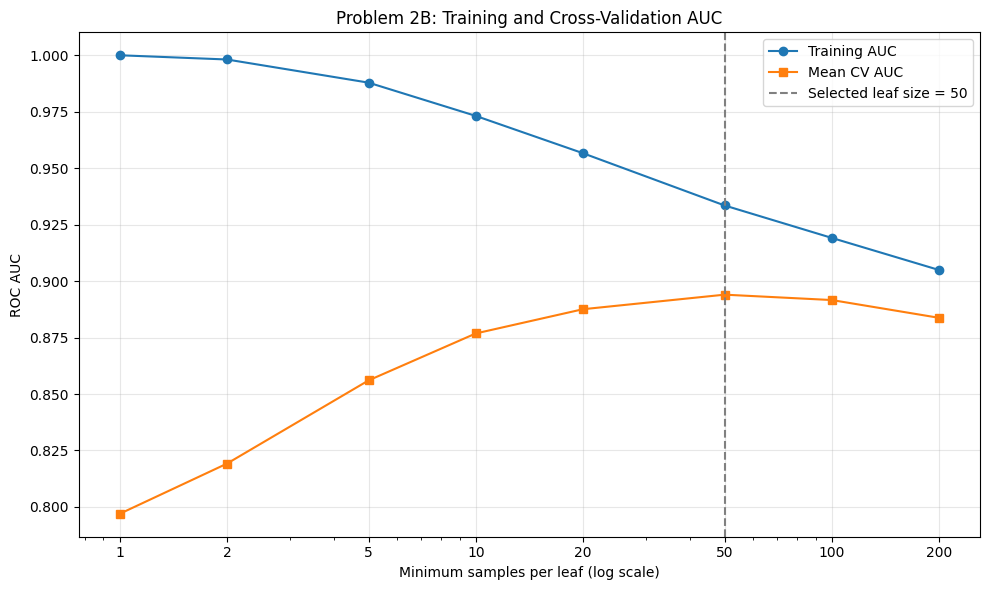

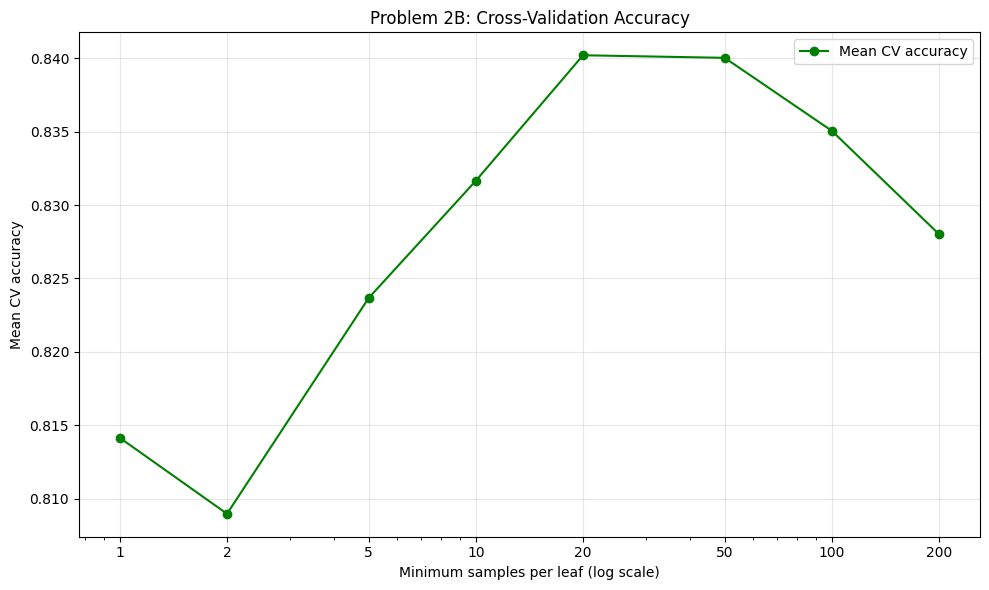

In [12]:
# Your code here, add as many cells as you need

# --------------------------------------------------
# Problem 2B: Explore min_samples_leaf
# --------------------------------------------------

leaf_values = [1, 2, 5, 10, 20, 50, 100, 200]
leaf_results = []

for leaf_size in leaf_values:

    # Vary only min_samples_leaf
    tree_model = DecisionTreeClassifier(
        min_samples_leaf=leaf_size,
        random_state=random_seed
    )

    # Reuse the same repeated cross-validation procedure
    cv_results = cross_validate(
        estimator=tree_model,
        X=X_development,
        y=y_development,
        cv=repeated_cv,
        scoring={
            "auc": "roc_auc",
            "accuracy": "accuracy"
        },
        n_jobs=-1,
        error_score="raise"
    )

    mean_cv_auc = cv_results["test_auc"].mean()
    mean_cv_accuracy = cv_results["test_accuracy"].mean()

    # Fit on the complete development set
    tree_model.fit(X_development, y_development)

    training_probabilities = tree_model.predict_proba(
        X_development
    )[:, 1]

    training_auc = roc_auc_score(
        y_development,
        training_probabilities
    )

    leaf_results.append({
        "min_samples_leaf": leaf_size,
        "training_auc": training_auc,
        "mean_cv_auc": mean_cv_auc,
        "mean_cv_accuracy": mean_cv_accuracy
    })

    print(
        f"Leaf size {leaf_size:3d} completed | "
        f"Training AUC: {training_auc:.4f} | "
        f"CV AUC: {mean_cv_auc:.4f} | "
        f"CV accuracy: {mean_cv_accuracy:.4f}",
        flush=True
    )

# Store the results for later problems
leaf_results_df = pd.DataFrame(leaf_results)

print("\nResults for all leaf sizes:")
display(leaf_results_df.round(4))

# Select using full-precision mean CV AUC
best_leaf_index = leaf_results_df["mean_cv_auc"].idxmax()
best_leaf_row = leaf_results_df.loc[best_leaf_index]
best_leaf = int(best_leaf_row["min_samples_leaf"])

print(f"\nSelected min_samples_leaf: {best_leaf}")
print(f"Best mean CV AUC: {best_leaf_row['mean_cv_auc']:.4f}")

# --------------------------------------------------
# Plot 1: Training and mean CV AUC
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    leaf_results_df["min_samples_leaf"],
    leaf_results_df["training_auc"],
    marker="o",
    label="Training AUC"
)

plt.plot(
    leaf_results_df["min_samples_leaf"],
    leaf_results_df["mean_cv_auc"],
    marker="s",
    label="Mean CV AUC"
)

plt.axvline(
    best_leaf,
    color="gray",
    linestyle="--",
    label=f"Selected leaf size = {best_leaf}"
)

plt.xscale("log")
plt.xticks(leaf_values, labels=[str(v) for v in leaf_values])
plt.xlabel("Minimum samples per leaf (log scale)")
plt.ylabel("ROC AUC")
plt.title("Problem 2B: Training and Cross-Validation AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# --------------------------------------------------
# Plot 2: Mean CV accuracy
# --------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    leaf_results_df["min_samples_leaf"],
    leaf_results_df["mean_cv_accuracy"],
    marker="o",
    color="green",
    label="Mean CV accuracy"
)

plt.xscale("log")
plt.xticks(leaf_values, labels=[str(v) for v in leaf_values])
plt.xlabel("Minimum samples per leaf (log scale)")
plt.ylabel("Mean CV accuracy")
plt.title("Problem 2B: Cross-Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [13]:
# Your answer here, NOT in the next cell

a2b = best_leaf      # Replace with the selected value of min_samples_leaf.

In [14]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2b = {a2b}')

a2b = 50


### Part C — `min_samples_split`

Repeat the same type of analysis for `min_samples_split`.

Choose a reasonable range of values that includes both small and substantially larger split thresholds.

For each value:

- Build a `DecisionTreeClassifier` using that value of `min_samples_split`.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set and compute its training ROC AUC.
- Store the results.
- Plot **training AUC and mean CV AUC** versus `min_samples_split`.
- Plot **mean CV accuracy** versus `min_samples_split`.
- Identify the value with the highest mean CV AUC.

Store your answer in:

```python
a2c = ...
```

where `a2c` is the selected value of `min_samples_split`.

**Hint:** As with `min_samples_leaf`, it may be useful to test values over a broad range rather than only values close to the default.


Results for min_samples_split:


,min_samples_split,training_auc,mean_cv_auc,mean_cv_accuracy
0,2,1.0000,0.7970,0.8141
1,5,0.9992,0.8116,0.8125
2,10,0.9956,0.8353,0.8144
3,20,0.9866,0.8577,0.8217
4,50,0.9703,0.8798,0.8315
5,100,0.9527,0.8886,0.8349
6,200,0.9347,0.8924,0.8344
7,500,0.9160,0.8862,0.8264
8,1000,0.8982,0.8776,0.8224



Selected min_samples_split: 200
Training AUC: 0.9347
Mean CV AUC: 0.8924
Mean CV accuracy: 0.8344


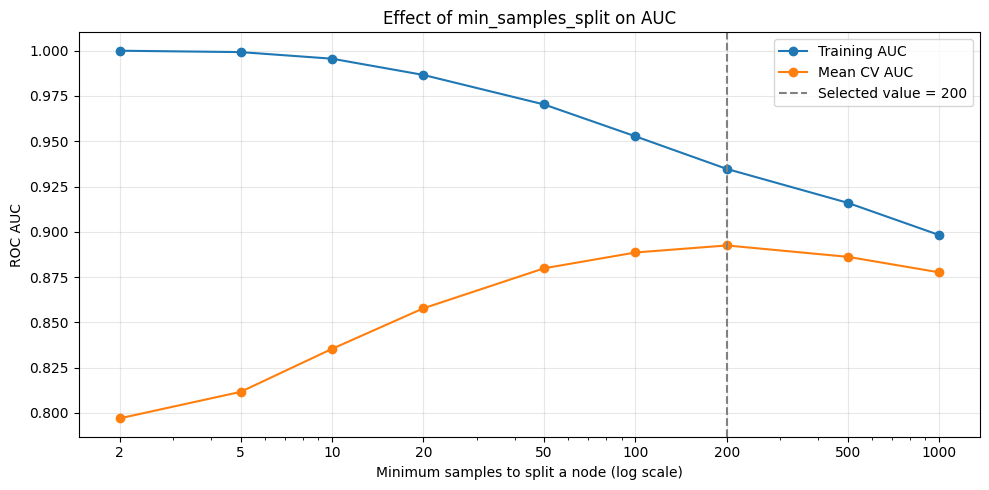

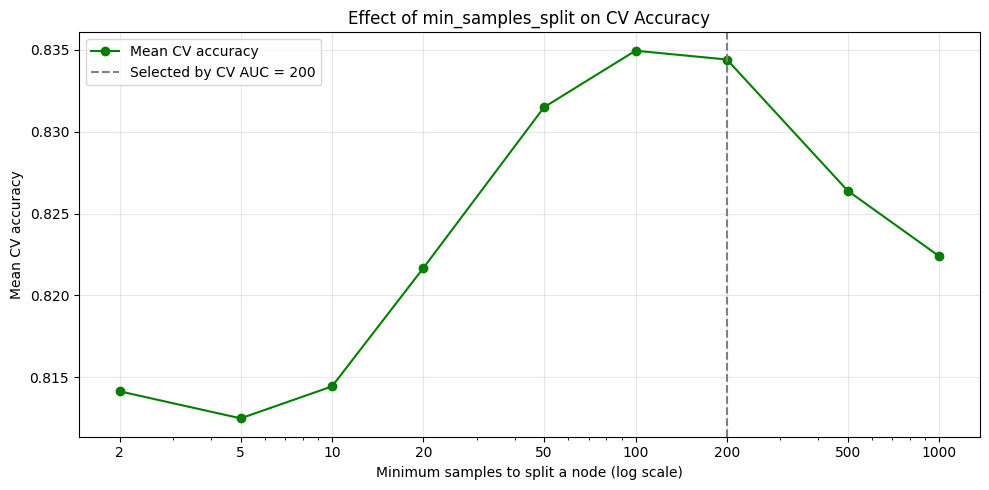

In [15]:
# Your code here, add as many cells as you need

# Problem 2C: Explore min_samples_split

split_values = [2, 5, 10, 20, 50, 100, 200, 500, 1000]
split_results = []

for split_size in split_values:

    # Vary only min_samples_split; other settings remain defaults.
    split_model = DecisionTreeClassifier(
        min_samples_split=split_size,
        random_state=random_seed
    )

    # Evaluate using the same repeated cross-validation.
    split_cv_results = cross_validate(
        split_model,
        X_development,
        y_development,
        cv=repeated_cv,
        scoring={
            "auc": "roc_auc",
            "accuracy": "accuracy"
        },
        n_jobs=-1,
        error_score="raise"
    )

    # Fit on the full development set to calculate training AUC.
    split_model.fit(X_development, y_development)

    training_probabilities = split_model.predict_proba(
        X_development
    )[:, 1]

    training_auc = roc_auc_score(
        y_development,
        training_probabilities
    )

    split_results.append({
        "min_samples_split": split_size,
        "training_auc": training_auc,
        "mean_cv_auc": split_cv_results["test_auc"].mean(),
        "mean_cv_accuracy": split_cv_results["test_accuracy"].mean()
    })

# Display results.
split_results_df = pd.DataFrame(split_results)

print("Results for min_samples_split:")
display(split_results_df.round(4))

# Select using full-precision mean CV AUC.
best_split_index = split_results_df["mean_cv_auc"].idxmax()
best_split_row = split_results_df.loc[best_split_index]
best_split = int(best_split_row["min_samples_split"])

print(f"\nSelected min_samples_split: {best_split}")
print(f"Training AUC: {best_split_row['training_auc']:.4f}")
print(f"Mean CV AUC: {best_split_row['mean_cv_auc']:.4f}")
print(
    f"Mean CV accuracy: "
    f"{best_split_row['mean_cv_accuracy']:.4f}"
)

# Plot 1: Training AUC and mean CV AUC.
plt.figure(figsize=(10, 5))

plt.plot(
    split_results_df["min_samples_split"],
    split_results_df["training_auc"],
    marker="o",
    label="Training AUC"
)

plt.plot(
    split_results_df["min_samples_split"],
    split_results_df["mean_cv_auc"],
    marker="o",
    label="Mean CV AUC"
)

plt.axvline(
    best_split,
    color="gray",
    linestyle="--",
    label=f"Selected value = {best_split}"
)

plt.xscale("log")
plt.xticks(split_values, split_values)
plt.xlabel("Minimum samples to split a node (log scale)")
plt.ylabel("ROC AUC")
plt.title("Effect of min_samples_split on AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# Plot 2: Mean CV accuracy.
plt.figure(figsize=(10, 5))

plt.plot(
    split_results_df["min_samples_split"],
    split_results_df["mean_cv_accuracy"],
    marker="o",
    color="green",
    label="Mean CV accuracy"
)

plt.axvline(
    best_split,
    color="gray",
    linestyle="--",
    label=f"Selected by CV AUC = {best_split}"
)

plt.xscale("log")
plt.xticks(split_values, split_values)
plt.xlabel("Minimum samples to split a node (log scale)")
plt.ylabel("Mean CV accuracy")
plt.title("Effect of min_samples_split on CV Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [16]:
# Your answer here, NOT in the next cell

a2c = best_split     # Replace with the selected value of `min_samples_split`.

In [17]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2c = {a2c}')

a2c = 200


## Problem 3 — Explore Hyperparameter Interactions

In Problem 2, you tuned `max_depth`, `min_samples_leaf`, and `min_samples_split` separately. However, the best value of one hyperparameter may depend on the settings of the others.

In this problem, investigate combinations of `min_samples_leaf` and `min_samples_split`.

Use:

```python
leaf_values = [5, 15, 30, 50]
split_values = [50, 100, 150, 200, 300]
```

For every combination of `min_samples_leaf` and `min_samples_split`:

- Build a `DecisionTreeClassifier` using both hyperparameter values.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set and compute its training ROC AUC.
- Store the results in a table.
- Identify the combination with the highest mean CV AUC.

Store your answers in:

```python
a3a = ...
a3b = ...
```

where:

- `a3a` is the selected value of `min_samples_leaf`
- `a3b` is the selected value of `min_samples_split`



In [18]:
# Your code here, add as many cells as you wish
# Problem 3: Explore hyperparameter interactions

combined_leaf_values = [5, 15, 30, 50]
combined_split_values = [50, 100, 150, 200, 300]

combined_results = []

for leaf_size in combined_leaf_values:
    for split_size in combined_split_values:

        # Tune both parameters together.
        combined_model = DecisionTreeClassifier(
            min_samples_leaf=leaf_size,
            min_samples_split=split_size,
            random_state=random_seed
        )

        # Evaluate using the same repeated cross-validation.
        combined_cv_results = cross_validate(
            combined_model,
            X_development,
            y_development,
            cv=repeated_cv,
            scoring={
                "auc": "roc_auc",
                "accuracy": "accuracy"
            },
            n_jobs=-1,
            error_score="raise"
        )

        # Calculate training AUC on the full development set.
        combined_model.fit(X_development, y_development)

        training_probabilities = combined_model.predict_proba(
            X_development
        )[:, 1]

        training_auc = roc_auc_score(
            y_development,
            training_probabilities
        )

        combined_results.append({
            "min_samples_leaf": leaf_size,
            "min_samples_split": split_size,
            "training_auc": training_auc,
            "mean_cv_auc": combined_cv_results["test_auc"].mean(),
            "mean_cv_accuracy": (
                combined_cv_results["test_accuracy"].mean()
            )
        })

        print(
            f"Completed: min_samples_leaf={leaf_size}, "
            f"min_samples_split={split_size}"
        )

# Create the results table.
combined_results_df = pd.DataFrame(combined_results)

print("\nResults ranked by mean CV AUC:")
display(
    combined_results_df.sort_values(
        "mean_cv_auc",
        ascending=False,
        kind="stable"
    ).round(4)
)

# Select the combination with the highest full-precision CV AUC.
best_combined_index = combined_results_df["mean_cv_auc"].idxmax()
best_combined_row = combined_results_df.loc[best_combined_index]

best_combined_leaf = int(
    best_combined_row["min_samples_leaf"]
)
best_combined_split = int(
    best_combined_row["min_samples_split"]
)

print("\nSelected combination:")
print(f"min_samples_leaf: {best_combined_leaf}")
print(f"min_samples_split: {best_combined_split}")
print(f"Training AUC: {best_combined_row['training_auc']:.4f}")
print(f"Mean CV AUC: {best_combined_row['mean_cv_auc']:.4f}")
print(
    f"Mean CV accuracy: "
    f"{best_combined_row['mean_cv_accuracy']:.4f}"
)

Completed: min_samples_leaf=5, min_samples_split=50
Completed: min_samples_leaf=5, min_samples_split=100
Completed: min_samples_leaf=5, min_samples_split=150
Completed: min_samples_leaf=5, min_samples_split=200
Completed: min_samples_leaf=5, min_samples_split=300
Completed: min_samples_leaf=15, min_samples_split=50
Completed: min_samples_leaf=15, min_samples_split=100
Completed: min_samples_leaf=15, min_samples_split=150
Completed: min_samples_leaf=15, min_samples_split=200
Completed: min_samples_leaf=15, min_samples_split=300
Completed: min_samples_leaf=30, min_samples_split=50
Completed: min_samples_leaf=30, min_samples_split=100
Completed: min_samples_leaf=30, min_samples_split=150
Completed: min_samples_leaf=30, min_samples_split=200
Completed: min_samples_leaf=30, min_samples_split=300
Completed: min_samples_leaf=50, min_samples_split=50
Completed: min_samples_leaf=50, min_samples_split=100
Completed: min_samples_leaf=50, min_samples_split=150
Completed: min_samples_leaf=50, min_s

,min_samples_leaf,min_samples_split,training_auc,mean_cv_auc,mean_cv_accuracy
2,5,150,0.9378,0.8942,0.8382
3,5,200,0.9315,0.8940,0.8360
15,50,50,0.9335,0.8940,0.8400
16,50,100,0.9335,0.8940,0.8400
8,15,200,0.9298,0.8937,0.8361
17,50,150,0.9271,0.8936,0.8385
7,15,150,0.9341,0.8935,0.8385
4,5,300,0.9246,0.8931,0.8339
6,15,100,0.9431,0.8929,0.8414
9,15,300,0.9236,0.8928,0.8335



Selected combination:
min_samples_leaf: 5
min_samples_split: 150
Training AUC: 0.9378
Mean CV AUC: 0.8942
Mean CV accuracy: 0.8382


In [19]:
# Your answer here, NOT in the next cell

a3a = best_combined_leaf      # Replace with the selected value of `min_samples_leaf` for problem 3

In [20]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3a = {a3a}')

a3a = 5


In [21]:
# Your answer here, NOT in the next cell

a3b = best_combined_split      # Replace with the selected value of `min_samples_split` for problem 3

In [22]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3b = {a3b}')

a3b = 150


## Problem 4 — Tune `ccp_alpha`

Use **cost-complexity pruning** to investigate another way of controlling decision-tree complexity.

For this problem, test the following range of pruning values:

```python
alpha_values = np.linspace(
    0.00015,
    0.00080,
    30
)
```

For each value of `ccp_alpha`:

- Build a `DecisionTreeClassifier` using that value.
- Use repeated cross-validation on the development set to compute:
  - mean ROC AUC
  - mean accuracy
- Fit the model on the complete development set.
- Compute the training ROC AUC.
- Store the results.

Then:

- Plot training AUC and mean CV AUC versus `ccp_alpha`.
- Plot mean CV accuracy separately.
- Determine which value of `ccp_alpha` produces the highest mean CV AUC.

Use **mean CV AUC** to select the best pruning value.

Store your answer in:

```python
a4 = ...
```

where `a4` is the selected value of `ccp_alpha`.

Completed 1/30: ccp_alpha = 0.00015000
Completed 2/30: ccp_alpha = 0.00017241
Completed 3/30: ccp_alpha = 0.00019483
Completed 4/30: ccp_alpha = 0.00021724
Completed 5/30: ccp_alpha = 0.00023966
Completed 6/30: ccp_alpha = 0.00026207
Completed 7/30: ccp_alpha = 0.00028448
Completed 8/30: ccp_alpha = 0.00030690
Completed 9/30: ccp_alpha = 0.00032931
Completed 10/30: ccp_alpha = 0.00035172
Completed 11/30: ccp_alpha = 0.00037414
Completed 12/30: ccp_alpha = 0.00039655
Completed 13/30: ccp_alpha = 0.00041897
Completed 14/30: ccp_alpha = 0.00044138
Completed 15/30: ccp_alpha = 0.00046379
Completed 16/30: ccp_alpha = 0.00048621
Completed 17/30: ccp_alpha = 0.00050862
Completed 18/30: ccp_alpha = 0.00053103
Completed 19/30: ccp_alpha = 0.00055345
Completed 20/30: ccp_alpha = 0.00057586
Completed 21/30: ccp_alpha = 0.00059828
Completed 22/30: ccp_alpha = 0.00062069
Completed 23/30: ccp_alpha = 0.00064310
Completed 24/30: ccp_alpha = 0.00066552
Completed 25/30: ccp_alpha = 0.00068793
Completed

,ccp_alpha,training_auc,mean_cv_auc,mean_cv_accuracy
0,0.00015000,0.9599,0.8466,0.8373
1,0.00017241,0.9533,0.8569,0.8407
2,0.00019483,0.9417,0.8668,0.8429
3,0.00021724,0.9356,0.8747,0.8438
4,0.00023966,0.9318,0.8818,0.8451
5,0.00026207,0.9301,0.8867,0.8468
6,0.00028448,0.9277,0.8889,0.8475
7,0.00030690,0.9258,0.8907,0.8474
8,0.00032931,0.9220,0.8918,0.8473
9,0.00035172,0.9194,0.8919,0.8476



Selected ccp_alpha: 0.0003741379
Training AUC: 0.9167
Mean CV AUC: 0.8921
Mean CV accuracy: 0.8480


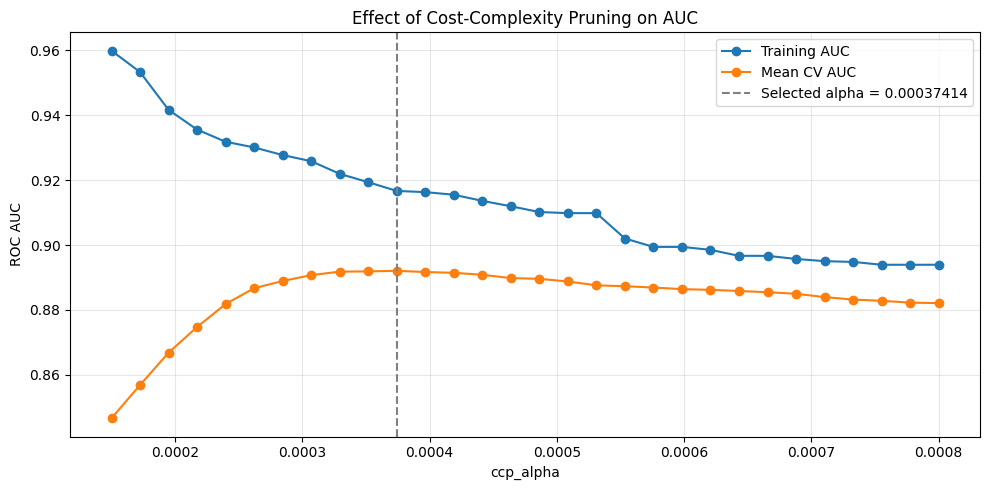

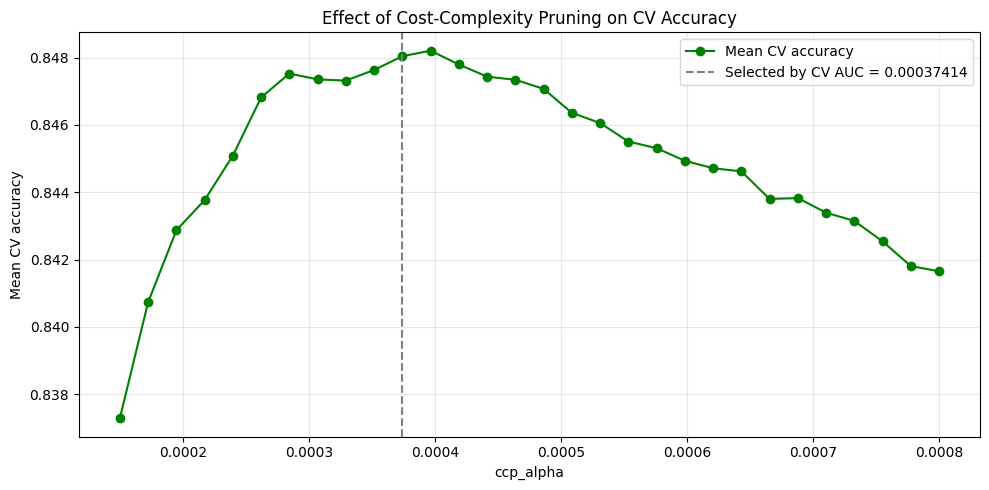

In [23]:
# Your code here, add as many cells as you wish
# Problem 4: Tune ccp_alpha

alpha_values = np.linspace(0.00015, 0.00080, 30)
alpha_results = []

for number, alpha in enumerate(alpha_values, start=1):

    # Change only the pruning parameter.
    pruned_model = DecisionTreeClassifier(
        ccp_alpha=float(alpha),
        random_state=random_seed
    )

    # Repeated cross-validation on the development set.
    alpha_cv_results = cross_validate(
        pruned_model,
        X_development,
        y_development,
        cv=repeated_cv,
        scoring={
            "auc": "roc_auc",
            "accuracy": "accuracy"
        },
        n_jobs=-1,
        error_score="raise"
    )

    # Fit on the complete development set.
    pruned_model.fit(X_development, y_development)

    # Calculate training ROC AUC.
    training_probabilities = pruned_model.predict_proba(
        X_development
    )[:, 1]

    training_auc = roc_auc_score(
        y_development,
        training_probabilities
    )

    # Store results for this alpha.
    alpha_results.append({
        "ccp_alpha": float(alpha),
        "training_auc": training_auc,
        "mean_cv_auc": alpha_cv_results["test_auc"].mean(),
        "mean_cv_accuracy": (
            alpha_cv_results["test_accuracy"].mean()
        )
    })

    print(
        f"Completed {number}/{len(alpha_values)}: "
        f"ccp_alpha = {alpha:.8f}"
    )

# Display all results.
alpha_results_df = pd.DataFrame(alpha_results)

print("\nPruning results:")
display(
    alpha_results_df.style.format({
        "ccp_alpha": "{:.8f}",
        "training_auc": "{:.4f}",
        "mean_cv_auc": "{:.4f}",
        "mean_cv_accuracy": "{:.4f}"
    })
)

# Select the alpha with the highest mean CV AUC.
# Selection uses full precision, not rounded values.
best_alpha_index = alpha_results_df["mean_cv_auc"].idxmax()
best_alpha_row = alpha_results_df.loc[best_alpha_index]
best_alpha = float(best_alpha_row["ccp_alpha"])

print(f"\nSelected ccp_alpha: {best_alpha:.10f}")
print(f"Training AUC: {best_alpha_row['training_auc']:.4f}")
print(f"Mean CV AUC: {best_alpha_row['mean_cv_auc']:.4f}")
print(
    f"Mean CV accuracy: "
    f"{best_alpha_row['mean_cv_accuracy']:.4f}"
)

# Plot 1: Training AUC and mean CV AUC.
plt.figure(figsize=(10, 5))

plt.plot(
    alpha_results_df["ccp_alpha"],
    alpha_results_df["training_auc"],
    marker="o",
    label="Training AUC"
)

plt.plot(
    alpha_results_df["ccp_alpha"],
    alpha_results_df["mean_cv_auc"],
    marker="o",
    label="Mean CV AUC"
)

plt.axvline(
    best_alpha,
    color="gray",
    linestyle="--",
    label=f"Selected alpha = {best_alpha:.8f}"
)

plt.xlabel("ccp_alpha")
plt.ylabel("ROC AUC")
plt.title("Effect of Cost-Complexity Pruning on AUC")
plt.ticklabel_format(axis="x", style="plain", useOffset=False)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# Plot 2: Mean CV accuracy.
plt.figure(figsize=(10, 5))

plt.plot(
    alpha_results_df["ccp_alpha"],
    alpha_results_df["mean_cv_accuracy"],
    marker="o",
    color="green",
    label="Mean CV accuracy"
)

plt.axvline(
    best_alpha,
    color="gray",
    linestyle="--",
    label=f"Selected by CV AUC = {best_alpha:.8f}"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Mean CV accuracy")
plt.title("Effect of Cost-Complexity Pruning on CV Accuracy")
plt.ticklabel_format(axis="x", style="plain", useOffset=False)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


In [24]:
# Your answer here, NOT in the next cell

a4 = best_alpha     # Replace with the selected value of `ccp_alpha`

In [25]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4 = {a4}')

a4 = 0.00037413793103448277


## Problem 5 — Compare Pre-Pruning and Cost-Complexity Pruning

You have now explored several ways to control the complexity of a decision tree.

Compare these three candidate models:

1. The **best single-hyperparameter tree** from Problem 2.
2. The **best two-hyperparameter tree** from Problem 3.
3. The **best `ccp_alpha`-pruned tree** from Problem 4.

Create a table containing, for each candidate:

- Training ROC AUC
- Mean CV ROC AUC
- Mean CV accuracy

Use the results you have already computed in Problems 2–4; you do **not** need to repeat the cross-validation.

Select the candidate with the highest **mean CV ROC AUC**.

Store your answer in:

```python
a5 = ...
```

using one of the following strings:

```python
"single"
"combined"
"pruned"
```

where:

- `"single"` = best single-hyperparameter model from Problem 2
- `"combined"` = best two-hyperparameter model from Problem 3
- `"pruned"` = best `ccp_alpha` model from Problem 4

Do not use the test set.

In [26]:
# Your code here, add as many cells as you need

# Problem 5: Compare the three tuning approaches.
# Reuse the results already computed in Problems 2–4.

metric_columns = [
    "training_auc",
    "mean_cv_auc",
    "mean_cv_accuracy"
]

# Find the best result from each single-parameter experiment.
single_candidates = []

for parameter, results_df in [
    ("max_depth", depth_results_df),
    ("min_samples_leaf", leaf_results_df),
    ("min_samples_split", split_results_df)
]:
    best_index = results_df["mean_cv_auc"].idxmax()
    best_row = results_df.loc[best_index]

    candidate = {
        "parameter": parameter,
        "value": int(best_row[parameter])
    }

    for metric in metric_columns:
        candidate[metric] = float(best_row[metric])

    single_candidates.append(candidate)

single_candidates_df = pd.DataFrame(single_candidates)

print("Best result from each Problem 2 experiment:")
display(single_candidates_df.round(4))

# Select the best single-parameter model across all three experiments.
best_single_index = single_candidates_df["mean_cv_auc"].idxmax()
best_single_row = single_candidates_df.loc[best_single_index]

best_single_parameter = str(best_single_row["parameter"])
best_single_value = int(best_single_row["value"])

# Save each candidate's settings for later problems.
best_single_params = {
    best_single_parameter: best_single_value
}

best_combined_params = {
    "min_samples_leaf": best_combined_leaf,
    "min_samples_split": best_combined_split
}

best_pruned_params = {
    "ccp_alpha": best_alpha
}

candidate_params = {
    "single": best_single_params,
    "combined": best_combined_params,
    "pruned": best_pruned_params
}

# Build the final comparison table from existing results.
comparison_results = []

for approach, result_row in [
    ("single", best_single_row),
    ("combined", best_combined_row),
    ("pruned", best_alpha_row)
]:
    comparison_row = {
        "approach": approach,
        "settings": str(candidate_params[approach])
    }

    for metric in metric_columns:
        comparison_row[metric] = float(result_row[metric])

    comparison_results.append(comparison_row)

comparison_results_df = pd.DataFrame(comparison_results)

print("\nComparison of the three approaches:")
display(
    comparison_results_df.style.format({
        "training_auc": "{:.4f}",
        "mean_cv_auc": "{:.4f}",
        "mean_cv_accuracy": "{:.4f}"
    })
)

# Select using full-precision mean CV AUC.
best_approach_index = comparison_results_df["mean_cv_auc"].idxmax()
best_approach_row = comparison_results_df.loc[best_approach_index]

best_approach = str(best_approach_row["approach"])
selected_tree_params = candidate_params[best_approach].copy()

print(f"\nSelected approach: {best_approach}")
print(f"Selected settings: {selected_tree_params}")
print(f"Training AUC: {best_approach_row['training_auc']:.4f}")
print(f"Mean CV AUC: {best_approach_row['mean_cv_auc']:.4f}")
print(
    f"Mean CV accuracy: "
    f"{best_approach_row['mean_cv_accuracy']:.4f}"
)

Best result from each Problem 2 experiment:


,parameter,value,training_auc,mean_cv_auc,mean_cv_accuracy
0,max_depth,7,0.9022,0.8771,0.8411
1,min_samples_leaf,50,0.9335,0.8940,0.8400
2,min_samples_split,200,0.9347,0.8924,0.8344



Comparison of the three approaches:


,approach,settings,training_auc,mean_cv_auc,mean_cv_accuracy
0,single,{'min_samples_leaf': 50},0.9335,0.8940,0.8400
1,combined,"{'min_samples_leaf': 5, 'min_samples_split': 150}",0.9378,0.8942,0.8382
2,pruned,{'ccp_alpha': 0.00037413793103448277},0.9167,0.8921,0.8480



Selected approach: combined
Selected settings: {'min_samples_leaf': 5, 'min_samples_split': 150}
Training AUC: 0.9378
Mean CV AUC: 0.8942
Mean CV accuracy: 0.8382


In [27]:
# Your answer here, NOT in the next cell

a5 = best_approach      # Replace with one of "single", "combined", or "pruned"

In [28]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5 = {a5}')

a5 = combined


## Problem 6 — Compare ROC Curves

Using the **Week 5 ROC-curve code** as a guide, compare the following models using cross-validated predictions on the development set:

- Logistic Regression baseline
- Best individually tuned decision tree from Problem 2
- Best two-parameter decision tree from Problem 3
- Best `ccp_alpha`-pruned decision tree from Problem 4

Plot all four ROC curves on the same graph and report the ROC AUC for each model in the legend.

Use a single 5-fold stratified cross-validation split for this plot:

```python
roc_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed
)
```

Use `cross_val_predict(..., method="predict_proba")` to obtain out-of-fold predicted probabilities for each model.

Then compute:

```python
a6 = ...
```

where `a6` is the difference between the ROC AUC of the **best decision-tree model** and the ROC AUC of Logistic Regression.



Logistic Regression: ROC AUC = 0.8394
Single-parameter tree: ROC AUC = 0.8936
Combined tree: ROC AUC = 0.8955
Pruned tree: ROC AUC = 0.8913


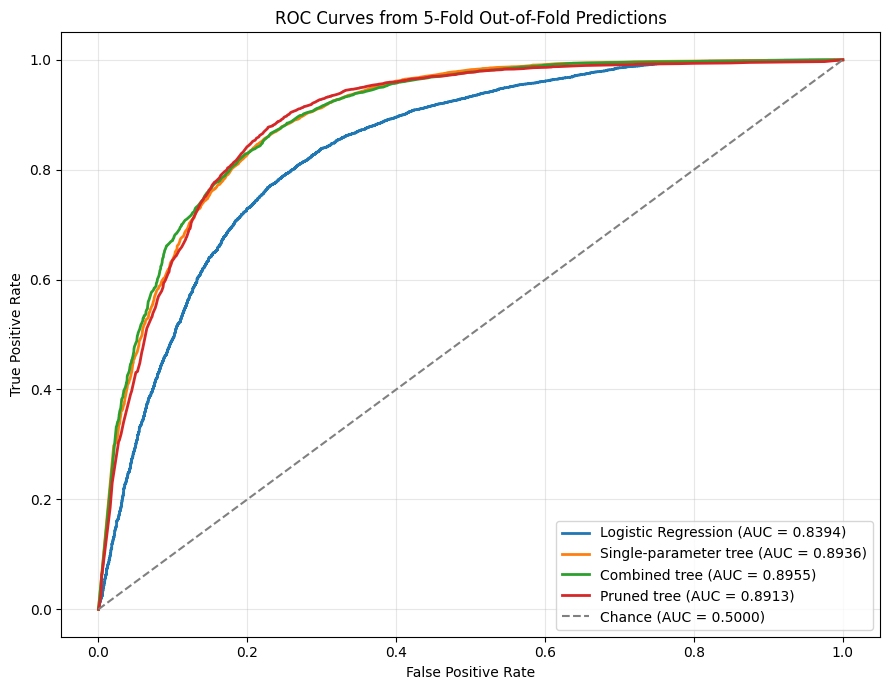


Best tree in the ROC comparison: Combined tree
Best tree ROC AUC: 0.8955
Logistic Regression ROC AUC: 0.8394
AUC difference: 0.0560


In [29]:
# Your code here, add as many cells as you wish

# Problem 6: Compare ROC curves using out-of-fold predictions

roc_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_seed
)

# Define the four models.
roc_models = {
    "Logistic Regression": clone(logistic_model),

    "Single-parameter tree": DecisionTreeClassifier(
        **best_single_params,
        random_state=random_seed
    ),

    "Combined tree": DecisionTreeClassifier(
        **best_combined_params,
        random_state=random_seed
    ),

    "Pruned tree": DecisionTreeClassifier(
        **best_pruned_params,
        random_state=random_seed
    )
}

roc_auc_scores = {}
roc_probabilities = {}

# Obtain out-of-fold probabilities for each model.
for model_name, model in roc_models.items():

    probabilities = cross_val_predict(
        model,
        X_development,
        y_development,
        cv=roc_cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    roc_probabilities[model_name] = probabilities

    roc_auc_scores[model_name] = roc_auc_score(
        y_development,
        probabilities
    )

    print(
        f"{model_name}: "
        f"ROC AUC = {roc_auc_scores[model_name]:.4f}"
    )

# Plot all four ROC curves together.
plt.figure(figsize=(9, 7))

for model_name, probabilities in roc_probabilities.items():

    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_development,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        linewidth=2,
        label=(
            f"{model_name} "
            f"(AUC = {roc_auc_scores[model_name]:.4f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    label="Chance (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves from 5-Fold Out-of-Fold Predictions")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

# Identify the decision tree with the highest AUC in this comparison.
tree_names = [
    "Single-parameter tree",
    "Combined tree",
    "Pruned tree"
]

best_roc_tree_name = max(
    tree_names,
    key=lambda name: roc_auc_scores[name]
)

best_tree_roc_auc = roc_auc_scores[best_roc_tree_name]
logistic_roc_auc = roc_auc_scores["Logistic Regression"]

auc_difference = best_tree_roc_auc - logistic_roc_auc

print(f"\nBest tree in the ROC comparison: {best_roc_tree_name}")
print(f"Best tree ROC AUC: {best_tree_roc_auc:.4f}")
print(f"Logistic Regression ROC AUC: {logistic_roc_auc:.4f}")
print(f"AUC difference: {auc_difference:.4f}")

In [30]:
# Your answer here, NOT in the next cell

a6 =  auc_difference     # Replace with the difference between the two ROC AUC scores

In [31]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6 = {a6:,.4f}')

a6 = 0.0560


## Problem 7 — Final Test Evaluation

Using the model selected in **Problem 5**, refit that model on the **complete development set**.

Then evaluate it **once** on the untouched test set.

Report:

- ROC AUC
- Accuracy
- F1 score
- True Positive Rate (TPR)
- False Positive Rate (FPR)

Also:

- display the confusion matrix
- plot the ROC curve for the test set

Do not use the test set to make any further model or hyperparameter choices.

Store the test ROC AUC in:

```python
a7 = ...
```


Selected approach: combined
Model settings: {'min_samples_leaf': 5, 'min_samples_split': 150}

Final test results:
ROC AUC: 0.9002
Accuracy: 0.8507
F1 score: 0.8887
True Positive Rate: 0.9197
False Positive Rate: 0.2765

Confusion matrix counts:
True negatives: 484
False positives: 185
False negatives: 99
True positives: 1134


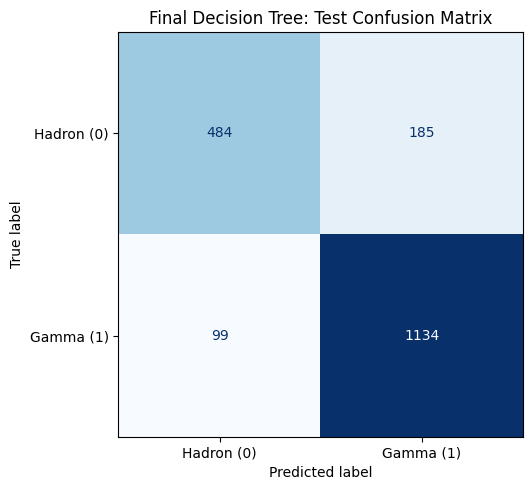

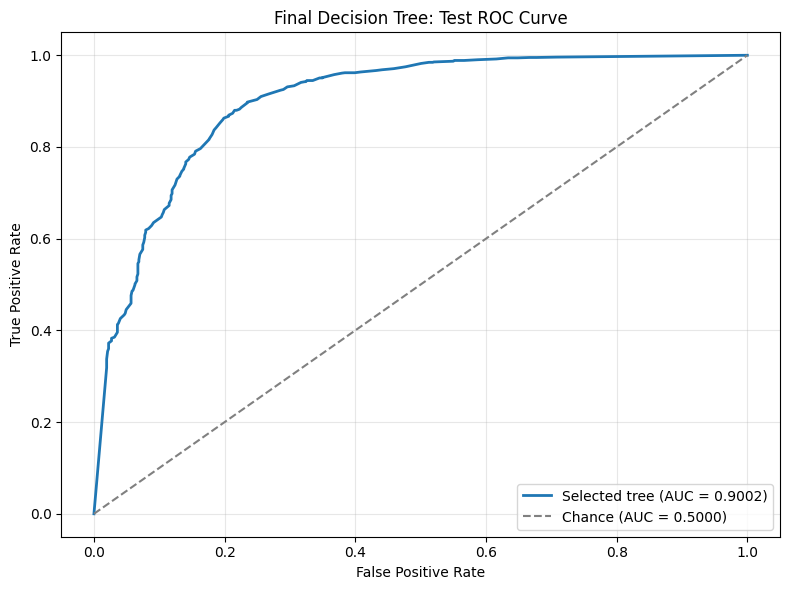

In [32]:
# Your code here, add as many cells as you wish
# Problem 7: Final test evaluation
# Use the model settings selected in Problem 5.

final_tree = DecisionTreeClassifier(
    **selected_tree_params,
    random_state=random_seed
)

# Train on the complete development set.
final_tree.fit(X_development, y_development)

# Obtain predictions on the held-out test set.
test_probabilities = final_tree.predict_proba(X_test)[:, 1]
test_predictions = final_tree.predict(X_test)

# Calculate test metrics.
test_auc = roc_auc_score(y_test, test_probabilities)
test_accuracy = accuracy_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions)

test_confusion_matrix = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
)

tn, fp, fn, tp = test_confusion_matrix.ravel()

test_tpr = tp / (tp + fn)
test_fpr = fp / (fp + tn)

# Display results.
print(f"Selected approach: {best_approach}")
print(f"Model settings: {selected_tree_params}")

print("\nFinal test results:")
print(f"ROC AUC: {test_auc:.4f}")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"F1 score: {test_f1:.4f}")
print(f"True Positive Rate: {test_tpr:.4f}")
print(f"False Positive Rate: {test_fpr:.4f}")

print("\nConfusion matrix counts:")
print(f"True negatives: {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives: {tp}")

# Plot the test confusion matrix.
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=["Hadron (0)", "Gamma (1)"]
).plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

ax.set_title("Final Decision Tree: Test Confusion Matrix")
plt.tight_layout()
plt.show()
plt.close()

# Plot the test ROC curve.
test_false_positive_rates, test_true_positive_rates, _ = roc_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    test_false_positive_rates,
    test_true_positive_rates,
    linewidth=2,
    label=f"Selected tree (AUC = {test_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle="--",
    label="Chance (AUC = 0.5000)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Decision Tree: Test ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [33]:
# Your answer here, NOT in the next cell

a7 = test_auc      # Replace with the test ROC AUC

In [34]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7 = {a7:,.4f}')

a7 = 0.9002


## Problem 8 — Multiple Choice

For each question, select the **best answer**.

### Part A — Hyperparameter Interactions

In Problem 2, you tuned `min_samples_leaf` and `min_samples_split` separately. In Problem 3, you varied them together.

Why might the values that performed best when tuned separately **not** form the best combination when used together?

1. Cross-validation cannot be used when more than one hyperparameter is varied.
2. The effect of one hyperparameter can depend on the value of another hyperparameter.
3. `min_samples_leaf` and `min_samples_split` control exactly the same property of a tree.
4. The individually selected values must always give the best result when combined.

In [35]:
# Your answer here, NOT in the next cell

a8a =2     # Replace with one of 1, 2, 3, 4

In [36]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8a = {a8a}')

a8a = 2


### Part B — Training vs. Cross-Validation Performance

During one of the hyperparameter sweeps, increasing the amount of regularization causes **training AUC to decrease while mean CV AUC increases**.

What is the most likely explanation?

1. The model is reducing overfitting and generalizing better to unseen data.
2. The model is becoming more complex and fitting the training data more closely.
4. Cross-validation is no longer valid because training AUC decreased.
5. The model should be selected using the highest training AUC instead.

In [37]:
# Your answer here, NOT in the next cell

a8b =  1     # Replace with one of 1, 2, 3, 4

In [38]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8b = {a8b}')

a8b = 1


### Part C — Pre-Pruning vs. Cost-Complexity Pruning

Suppose the best manually tuned combination of stopping hyperparameters has a slightly higher mean CV AUC than the best `ccp_alpha` model.

Which conclusion is most appropriate?

1. Pre-pruning is always better than cost-complexity pruning.
2. Cost-complexity pruning should never be used when stopping criteria are available.
3. For this dataset and the settings investigated, the pre-pruned model performed somewhat better according to mean CV AUC.
4. The `ccp_alpha` model must have been implemented incorrectly.

In [39]:
# Your answer here, NOT in the next cell

a8c = 3     # Replace with one of 1, 2, 3, 4

In [40]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8c = {a8c}')

a8c = 3


### Part D — Crossing ROC Curves

In Problem 6, suppose the ROC curves for two decision-tree models cross.

What does this imply?

1. One of the ROC curves must have been calculated incorrectly.
2. The model with the larger overall AUC must have a higher TPR at every possible FPR.
3. Which model is preferable may depend on the desired operating region, even if one model has a slightly larger overall AUC.
4. The two models must have exactly the same AUC.

In [41]:
# Your answer here, NOT in the next cell

a8d = 3     # Replace with one of 1, 2, 3, 4

In [42]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8d = {a8d}')

a8d = 3


### Part E — AUC vs. Accuracy
Suppose two decision-tree models have very similar mean CV accuracy, but one has a noticeably higher mean CV ROC AUC.
What does this suggest?
1. The model with higher AUC is necessarily more accurate at the default classification threshold.
2. Accuracy and ROC AUC measure exactly the same aspect of model performance.
3. The model with lower AUC should always be selected if its training accuracy is higher.
4. The model with higher AUC does a better job ranking positive cases above negative cases across possible thresholds.


In [43]:
# Your answer here, NOT in the next cell

a8e = 4     # Replace with one of 1, 2, 3, 4

In [44]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a8e = {a8e}')

a8e = 4


## Problem 9 — Reflection

In a short paragraph, reflect on what you learned from tuning the decision tree in this homework.

Your response should address all of the following:

- How did the different hyperparameters affect the balance between **underfitting and overfitting**?
- What did you learn from comparing hyperparameters **one at a time** with tuning them **in combination**?
- How did the best pre-pruned model compare with the best `ccp_alpha`-pruned model?
- Why is cross-validation useful for making these choices before evaluating the final model on the test set?


In [45]:
a9 = """I found that tuning decision trees achieves a balance between underfitting and overfitting.

A limited max_depth can result in an overly simple tree, while an increased depth may cause it to overfit.

Increasing min_samples_leaf, min_samples_split, or ccp_alpha reduces model complexity and can reduce overfitting, although excessive regularization may result in underfitting.

Tuning hyperparameters in isolation facilitated my grasp of their individual effects, whereas simultaneous tuning demonstrated their interactions.

The separately selected leaf and split values were 50 and 200; however, the best-performing tested combination utilized min_samples_leaf=5 and min_samples_split=150.

This combined pre-pruned model achieved a mean CV AUC of 0.8942 and outperformed the best ccp_alpha-pruned model in the comparison.

This result is relevant to the dataset and hyperparameter settings evaluated; it does not suggest that pre-pruning is always superior.

Cross-validation facilitated the comparison of models on held-out development folds while ensuring the test set remained untouched for final evaluation.

Following the selection of the model, the final test ROC AUC achieved a value of 0.9002."""

In [46]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print("a9 =")
print(a9)

a9 =
I found that tuning decision trees achieves a balance between underfitting and overfitting.

A limited max_depth can result in an overly simple tree, while an increased depth may cause it to overfit.

Increasing min_samples_leaf, min_samples_split, or ccp_alpha reduces model complexity and can reduce overfitting, although excessive regularization may result in underfitting.

Tuning hyperparameters in isolation facilitated my grasp of their individual effects, whereas simultaneous tuning demonstrated their interactions.

The separately selected leaf and split values were 50 and 200; however, the best-performing tested combination utilized min_samples_leaf=5 and min_samples_split=150.

This combined pre-pruned model achieved a mean CV AUC of 0.8942 and outperformed the best ccp_alpha-pruned model in the comparison.

This result is relevant to the dataset and hyperparameter settings evaluated; it does not suggest that pre-pruning is always superior.

Cross-validation facilitated the 

### Appendix: Which `DecisionTreeClassifier` Parameters Are Most Important?

Decision trees have many hyperparameters, but some have a much greater effect on **model complexity, overfitting, and generalization** than others. When first working with decision trees, it is useful to focus on the parameters that most directly control how large and detailed the tree can become.

In this homework, we focus on four especially important complexity controls:

---

1. **`max_depth`** (default: `None`)  
   *Sets the maximum depth of the tree. Smaller values produce simpler trees that may underfit, while larger values allow more complex trees that may overfit.*

2. **`min_samples_leaf`** (default: `1`)  
   *Sets the minimum number of training samples that must remain in a leaf node. Larger values prevent very small, highly specialized leaves and can reduce overfitting.*

3. **`min_samples_split`** (default: `2`)  
   *Sets the minimum number of training samples required before an internal node is allowed to split. Larger values prevent the tree from continuing to split small groups of observations.*

4. **`ccp_alpha`** (default: `0.0`)  
   *Controls Minimal Cost-Complexity Pruning. Larger values penalize complex trees more strongly, causing more branches to be removed after the tree is grown.*

---

Other useful parameters include:

5. **`max_leaf_nodes`** (default: `None`)  
   *Limits the total number of leaf nodes in the tree. Like `max_depth`, it provides a direct way to restrict overall tree size.*

6. **`min_impurity_decrease`** (default: `0.0`)  
   *Allows a split only when it reduces impurity by at least the specified amount. Larger values therefore make the tree more conservative about creating new branches.*

7. **`criterion`** (default: `"gini"` for `DecisionTreeClassifier`)  
   *Determines how the quality of a split is measured. Common choices for classification include `"gini"` and `"entropy"`.*

8. **`splitter`** (default: `"best"`)  
   *Controls how candidate splits are selected at each node. `"best"` searches for the strongest split, while `"random"` introduces additional randomness.*

9. **`max_features`** (default: `None`)  
   *Limits the number of predictor variables considered when searching for a split. This is especially important in ensemble methods such as Random Forests.*

10. **`min_weight_fraction_leaf`** (default: `0.0`)  
    *Specifies the minimum weighted fraction of the training data that must appear in a leaf. It is mainly useful when observations have sample weights.*

11. **`random_state`** (default: `None`)  
    *Controls reproducibility when randomness is involved in fitting the tree. Setting `random_state=random_seed` makes repeated runs reproducible.*

---

For this homework, the main goal is not to explore every available setting, but to understand how a few important hyperparameters control **tree complexity**, how those hyperparameters can **interact**, and how cross-validation can be used to choose among candidate models.